In [6]:
import yfinance as yf
from joblib import Memory
import pandas as pd
import numpy as np

# Setting up cache to avoid redundant data fetches
cache_dir = './cache'
memory = Memory(location=cache_dir, verbose=0)

@memory.cache
def fetch_stock_data(ticker):
  """Fetch historical data for a given ticker."""
  try:
    ticker_obj = yf.Ticker(ticker)
    data = ticker_obj.history(period="max")
    return data
  except Exception as e:
    print(f"Error fetching data for {ticker}: {str(e)}")
    return pd.DataFrame()

In [7]:
# Define Stock List and Fetch Data

stock_list = [
    'AAPL', 'MSFT', 'GOOGL', 'NVDA', 'CRM', 'ORCL',  # Technology
    'JNJ', 'PFE', 'MRK', 'ABT', 'BMY', 'TMO',        # Healthcare
    'JPM', 'BAC', 'GS', 'MS', 'C', 'WFC',            # Financials
    'AMZN', 'TSLA', 'NKE', 'HD', 'MCD', 'BKNG',      # Consumer Discretionary
    'PG', 'KO', 'PEP', 'WMT', 'COST', 'KHC',         # Consumer Staples
    'XOM', 'CVX', 'SLB', 'COP', 'PSX', 'MPC',        # Energy
    'BA', 'HON', 'MMM', 'CAT', 'GE', 'DE',           # Industrials
    'VZ', 'T', 'CMCSA', 'TMUS', 'CHTR',              # Communication Services
    'AMT', 'SPG', 'EQIX', 'O', 'CCI'                 # Real Estate
]

# Dictionary to store data for each stock
stock_data = {}

# Fetch and store data for each stock
for ticker in stock_list:
  stock_data[ticker] = fetch_stock_data(ticker)

# Save the fetched data to CSV files
for ticker, data in stock_data.items():
    data.to_csv(f'raw_data_{ticker}.csv')

print("Data fetched successfully for all stocks!")


Data fetched successfully for all stocks!


               Open          High           Low         Close        Volume  \
count  10944.000000  10944.000000  10944.000000  10944.000000  1.094400e+04   
mean      20.580304     20.801852     20.367313     20.593375  3.193253e+08   
std       43.728874     44.196658     43.289134     43.762683  3.357990e+08   
min        0.038331      0.038331      0.037900      0.037900  0.000000e+00   
25%        0.241558      0.246475      0.236631      0.241563  1.142134e+08   
50%        0.424472      0.431722      0.418599      0.426029  2.070096e+08   
75%       16.990424     17.137179     16.813703     16.980132  3.995229e+08   
max      197.499763    199.095551    196.482439    197.589523  7.421641e+09   

          Dividends  Stock Splits  
count  10944.000000  10944.000000  
mean       0.000756      0.001553  
std        0.011782      0.083869  
min        0.000000      0.000000  
25%        0.000000      0.000000  
50%        0.000000      0.000000  
75%        0.000000      0.000000  


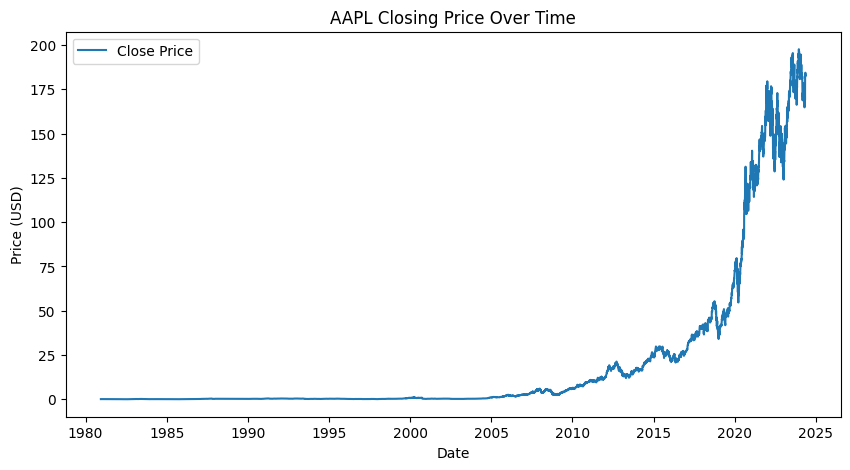

In [8]:
# Initial EDA - Undersanding the Basics about the data fetched

import matplotlib.pyplot as plt

ticker = 'AAPL'
data = pd.read_csv(f'raw_data_{ticker}.csv', index_col='Date', parse_dates=True)

# Display basic stats
print(data.describe())

# Plot the closing prices of the selected stock or ticker
plt.figure(figsize=(10, 5))
plt.plot(data['Close'], label='Close Price')
plt.title(f'{ticker} Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


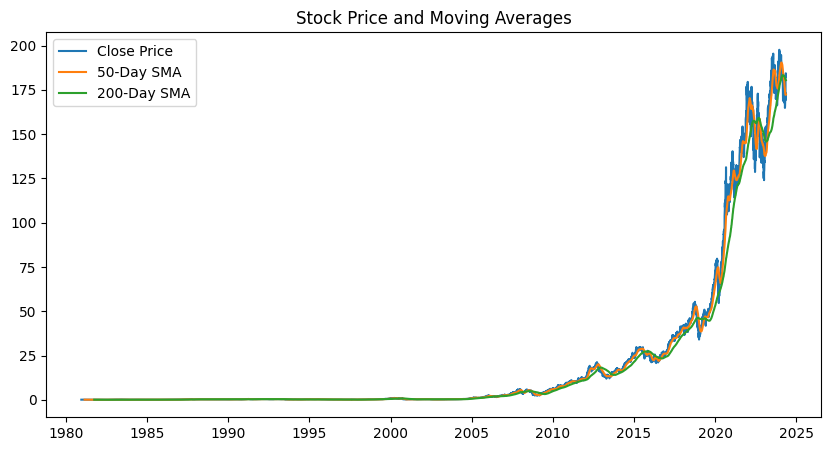

In [10]:
# SMA Analysis
data['Returns'] = data['Close'].pct_change()
data['SMA_50'] = data['Close'].rolling(window=50).mean() # 50-Day SMA
data['SMA_200'] = data['Close'].rolling(window=200).mean() # 200-day SMA

plt.figure(figsize=(10, 5))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['SMA_50'], label='50-Day SMA')
plt.plot(data['SMA_200'], label='200-Day SMA')
plt.title('Stock Price and Moving Averages')
plt.legend()
plt.show()